## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [2]:
df = pd.read_csv('/Volumes/Zweidrive/QueryResults.csv')

**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [3]:
df.head()
df.tail()

,m,TagName,Unnamed: 2
3008,2026-08-01 00:00:00,php,21
3009,2026-08-01 00:00:00,python,150
3010,2026-08-01 00:00:00,r,27
3011,2026-08-01 00:00:00,ruby,3
3012,2026-08-01 00:00:00,swift,19


**Challenge:** Check how many rows and how many columns there are. 
What are the dimensions of the dataframe?

In [4]:
rows, columns = df.shape

print(rows)
print(columns)
df.shape

3013
3


(3013, 3)

**Challenge**: Count the number of entries in each column of the dataframe

In [5]:
clean_df = df.dropna()
clean_df.tail()

,m,TagName,Unnamed: 2
3008,2026-08-01 00:00:00,php,21
3009,2026-08-01 00:00:00,python,150
3010,2026-08-01 00:00:00,r,27
3011,2026-08-01 00:00:00,ruby,3
3012,2026-08-01 00:00:00,swift,19


**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [6]:
post_counts = clean_df.groupby("TagName")["Unnamed: 2"].sum()
print(post_counts)

TagName
assembly        45073
c              407965
c#            1621715
c++            813981
delphi          52544
go              74457
java          1914382
javascript    2521705
perl            68295
php           1460900
python        2204505
r              510337
ruby           229120
swift          336108
Name: Unnamed: 2, dtype: int64


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [7]:
months_per_language = clean_df.groupby("TagName")["m"].nunique()
print("The number of months of data that exist per language are as follows:\n")
print(months_per_language)
language_with_fewest_months_with_entry=months_per_language.idxmin()
print(f"The language with the fewest months with an entry is {language_with_fewest_months_with_entry}")

The number of months of data that exist per language are as follows:

TagName
assembly      217
c             217
c#            218
c++           217
delphi        217
go            202
java          217
javascript    217
perl          217
php           217
python        217
r             215
ruby          217
swift         208
Name: m, dtype: int64
The language with the fewest months with an entry is go


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [8]:
clean_df["m"] = pd.to_datetime(clean_df["m"])
clean_df.head()

,m,TagName,Unnamed: 2
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,c,81
3,2008-08-01,c#,503
4,2008-08-01,c++,164


## Data Manipulation



**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [9]:
rows, columns = clean_df.shape
print(rows)
print(columns)

3013
3


In [10]:
print(clean_df.columns)

Index(['m', 'TagName', 'Unnamed: 2'], dtype='str')


In [11]:
df.head()

,m,TagName,Unnamed: 2
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,c,81
3,2008-08-01 00:00:00,c#,503
4,2008-08-01 00:00:00,c++,164


**Challenge**: Count the number of entries per programming language. Why might the number of entries be different? 

In [12]:
entries_per_language = df.groupby("TagName")["m"].count().nunique
print(entries_per_language)

<bound method IndexOpsMixin.nunique of TagName
assembly      217
c             217
c#            218
c++           217
delphi        217
go            202
java          217
javascript    217
perl          217
php           217
python        217
r             215
ruby          217
swift         208
Name: m, dtype: int64>


The number of entries might be different per programming language simply due to the fact that not all of the programming languages existed at the time the dataset's first sample point was collected. As an example, the first assembly language was created in 1947 by Kathleen Booth, whereas Swift was first unveiled by Apple at WWDC 2014 and created sometime prior.

## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

In [13]:
swift = (clean_df[clean_df["TagName"] == "swift"].groupby("m")["Unnamed: 2"].sum())

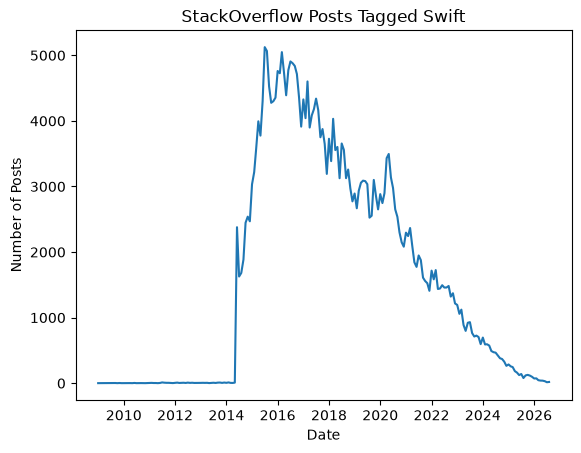

In [14]:
plt.plot(swift.index, swift.values)
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.title("StackOverflow Posts Tagged Swift")
plt.show()

**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

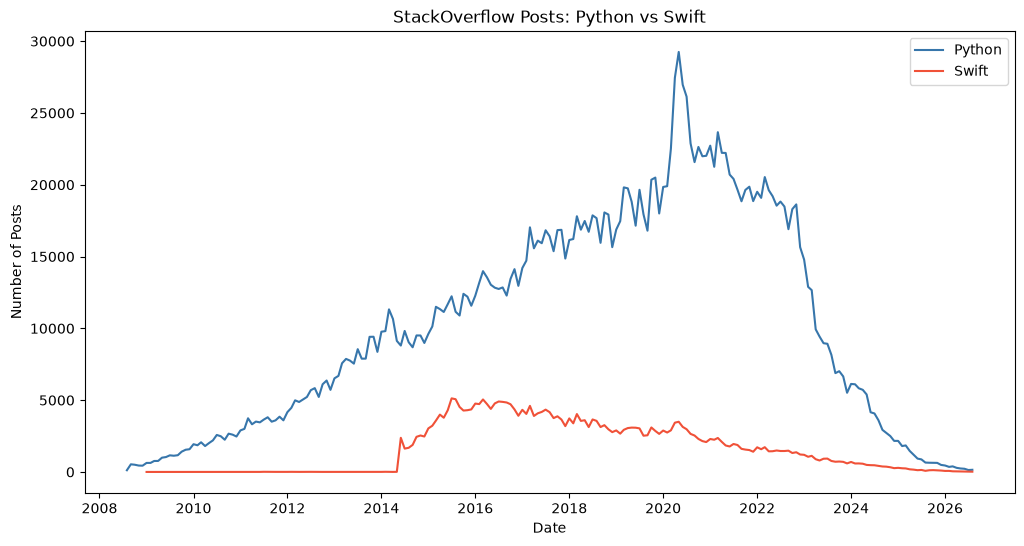

In [ ]:
python = (clean_df[clean_df["TagName"] == "python"].groupby("m")["Unnamed: 2"].sum())
swift = (clean_df[clean_df["TagName"] == "swift"].groupby("m")["Unnamed: 2"].sum())
plt.figure(figsize=(12, 6))
plt.plot(python.index, python.values, color="#3776AB", label="Python")
plt.plot(swift.index, swift.values, color="#F05138", label="Swift")
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.title("StackOverflow Posts: Python vs Swift")
plt.legend()
plt.show()


# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 

In [16]:
swift = swift.rolling(window=6).mean()
python = python.rolling(window=6).mean()

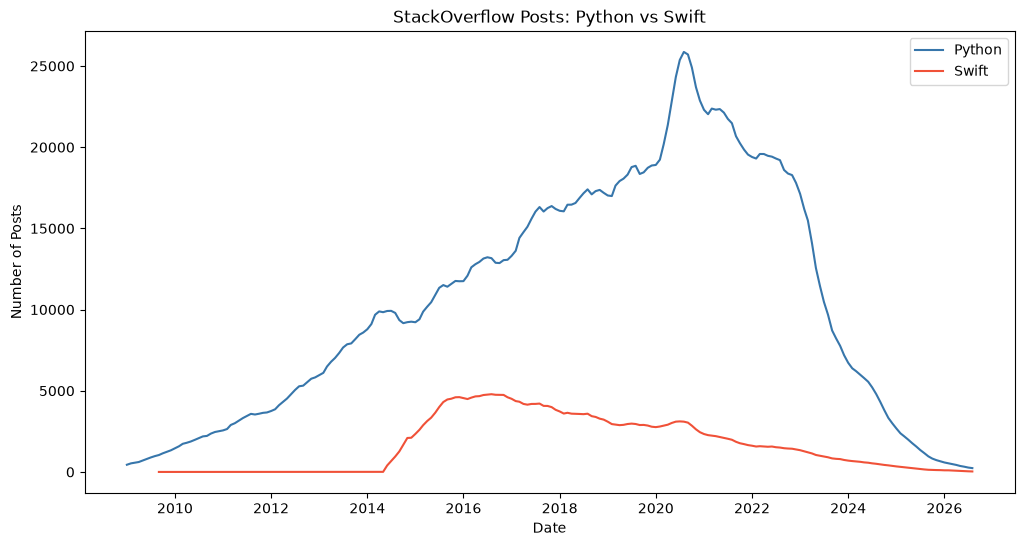

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(python.index, python.values, color="#3776AB", label="Python")
plt.plot(swift.index, swift.values, color="#F05138", label="Swift")
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.title("StackOverflow Posts: Python vs Swift")
plt.legend()
plt.show()